# Base Model Training

Train a logistic regression baseline on the prepared fraud dataset and evaluate it on the held-out test split.

In [1]:
import warnings

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')

# Keep the run reproducible.
seed = 42
np.random.seed(seed)

print('Imports and seed set.')

Imports and seed set.


## 1. Imports & Setup

Import the libraries and set the random seed for reproducible results.

In [2]:
from pathlib import Path

# Resolve the repository root so artifact paths work from any notebook working directory.
BASE_DIR = None
for candidate in [Path.cwd()] + list(Path.cwd().parents):
    if (candidate / 'artifacts').exists() or (candidate / 'requirements.txt').exists() or (candidate / 'README.md').exists():
        BASE_DIR = candidate
        break
if BASE_DIR is None:
    BASE_DIR = Path.cwd()
    print('Warning: repository root not found; using CWD as BASE_DIR')

ARTIFACT_DIR = BASE_DIR / 'artifacts'

if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(
        f'Artifact directory not found: {ARTIFACT_DIR}. Run the data preparation notebook first.'
    )

# Load the arrays saved by the data preparation notebook.
X_train = np.load(ARTIFACT_DIR / 'credit_card_fraud_X_train.npz')['X_train']
y_train = np.load(ARTIFACT_DIR / 'credit_card_fraud_y_train.npz')['y_train']
X_test = np.load(ARTIFACT_DIR / 'credit_card_fraud_X_test.npz')['X_test']
y_test = np.load(ARTIFACT_DIR / 'credit_card_fraud_y_test.npz')['y_test']

print(f'BASE_DIR: {BASE_DIR}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

BASE_DIR: c:\Users\yshan\Desktop\end-to-end-credit-card-fraud-detection-system
X_train shape: (15758, 12)
X_test shape: (2000, 12)
y_train shape: (15758,)
y_test shape: (2000,)


## 2. Load Prepared Artifacts

Read the train/test arrays produced by the data preparation notebook.

In [3]:
# Fit a logistic regression baseline on the resampled training split.
model_lr = LogisticRegression(random_state=seed, max_iter=1000)
model_lr.fit(X_train, y_train)

print('Logistic regression model trained.')

Logistic regression model trained.


## 3. Train Logistic Regression

Fit a logistic regression baseline on the prepared training data.

In [4]:
# Predict labels and class probabilities for both splits.
y_hat_train = model_lr.predict(X_train)
y_hat_test = model_lr.predict(X_test)

y_proba_train = model_lr.predict_proba(X_train)
y_proba_test = model_lr.predict_proba(X_test)

print('Predictions generated.')

Predictions generated.


## 5. Evaluate Performance

Measure the baseline model with standard classification metrics.

## 4. Make Predictions

Generate class predictions and probabilities for the train and test splits.

In [5]:
accuracy = accuracy_score(y_test, y_hat_test)
precision = precision_score(y_test, y_hat_test)
recall = recall_score(y_test, y_hat_test)
f1 = f1_score(y_test, y_hat_test)

print(f'accuracy : {accuracy}')
print(f'precision : {precision}')
print(f'recall : {recall}')
print(f'f1_score : {f1}')

accuracy : 0.961
precision : 0.2777777777777778
recall : 1.0
f1_score : 0.43478260869565216


## 6. Confusion Matrix

Visualize the test-set classification outcomes.

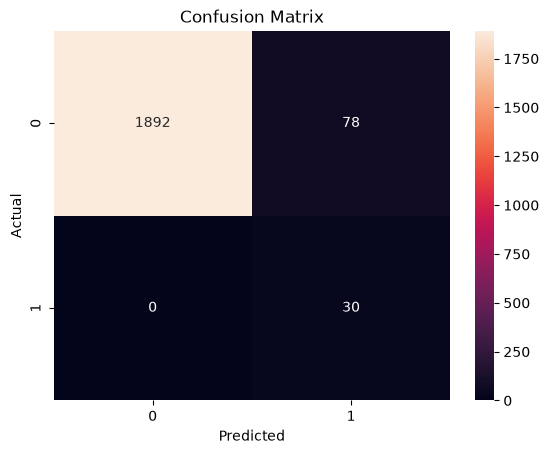

In [6]:
cm = confusion_matrix(y_test, y_hat_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()